In [1]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
print("Téléchargement des données")
tickers_portfolio = ["TTE.PA", "SHEL.L", "BP.L", "ENI.MI", "EQNR.OL", "REP.MC"]
tickers_macro = ["BZ=F", "EURUSD=X", "^STOXX50E", "^VIX"] 

data_port = yf.download(tickers_portfolio, start="2015-01-01", end="2026-03-31")['Close']
data_macro = yf.download(tickers_macro, start="2015-01-01", end="2026-03-31")['Close']

data_macro.head()


[*********************100%***********************]  6 of 6 completed

Téléchargement des données



[*********************100%***********************]  4 of 4 completed


Ticker,BZ=F,EURUSD=X,^STOXX50E,^VIX
Date,,,,
2015-01-01,NaN,1.209863,NaN,NaN
2015-01-02,56.419998,1.208941,NaN,17.790001
2015-01-05,53.110001,1.194643,3023.139893,19.920000
2015-01-06,51.099998,1.193902,NaN,21.120001
2015-01-07,51.150002,1.187536,3026.790039,19.309999


In [11]:
data_port.head()

Ticker,BP.L,ENI.MI,EQNR.OL,REP.MC,SHEL.L,TTE.PA
Date,,,,,,
2015-01-02,407.630188,7.060860,70.260712,7.539683,2155.130859,21.431875
2015-01-05,387.022644,6.470440,68.046478,7.099023,2067.653809,20.149244
2015-01-06,388.363373,6.557552,68.748558,7.077231,2067.156738,20.118998
2015-01-07,391.044952,6.591429,69.396645,7.113549,2085.546143,20.575113
2015-01-08,402.217560,6.847921,69.990685,7.292720,2129.781250,21.368881


In [10]:
print("Calcul des rendements et création du portefeuille")
rendements_port = data_port.pct_change().dropna()
rendements_macro = data_macro.pct_change().dropna()
rendements_macro.columns = ["Brent", "EUR_USD", "EuroStoxx", "VIX"]

rendement_port = rendements_port.mean(axis=1)

macro_decalee = rendements_macro.shift(1).dropna()

df_complet = pd.concat([rendement_port.rename("Cible"), macro_decalee], axis=1).dropna()

df_complet.to_csv("dataset_propre.csv")

df_complet.head()

Calcul des rendements et création du portefeuille


C:\Users\Tomle\AppData\Local\Temp\ipykernel_26720\2150123624.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rendements_port = data_port.pct_change().dropna()
C:\Users\Tomle\AppData\Local\Temp\ipykernel_26720\2150123624.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rendements_macro = data_macro.pct_change().dropna()


,Cible,Brent,EUR_USD,EuroStoxx,VIX
Date,,,,,
2015-01-07,0.009699,-0.037846,-0.000621,0.000000,0.060241
2015-01-08,0.026837,0.000979,-0.005332,0.001207,-0.085701
2015-01-09,-0.021558,-0.003715,-0.003314,0.035777,-0.119109
2015-01-12,-0.008770,-0.016680,-0.003374,-0.029403,0.031746
2015-01-13,0.011008,-0.053482,0.006327,0.013566,0.116809


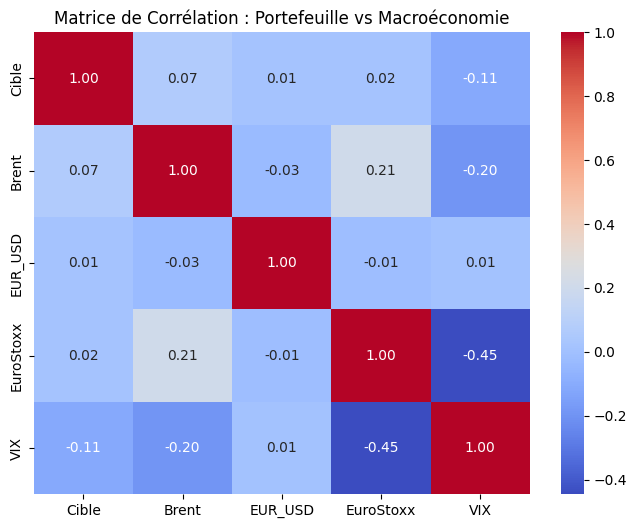

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_complet.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélation : Portefeuille vs Macroéconomie")
plt.show()

À première vue, les corrélations entre les variables macroéconomiques (à T-1) et le rendement de notre portefeuille (à T) sont très faibles, la plus marquée étant le VIX à -0.11.